# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

from scipy.stats import chi2_contingency, ttest_ind
from sklearn.model_selection import train_test_split

#models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report, f1_score, roc_curve, auc

# Importing the File

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("krishnaraj30/finance-loan-approval-prediction-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'finance-loan-approval-prediction-data' dataset.
Path to dataset files: /kaggle/input/finance-loan-approval-prediction-data


In [ ]:
os.listdir(path)

['train.csv', 'test.csv']

In [ ]:
file_location = os.path.join(path, 'train.csv')
df = pd.read_csv(file_location)
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
for col in ['Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']:
    print(f"Unique values for column '{col}': {df[col].unique()}")

Unique values for column 'Married': ['No' 'Yes' nan]
Unique values for column 'Dependents': ['0' '1' '2' '3+' nan]
Unique values for column 'Education': ['Graduate' 'Not Graduate']
Unique values for column 'Self_Employed': ['No' 'Yes' nan]
Unique values for column 'Credit_History': [ 1.  0. nan]
Unique values for column 'Property_Area': ['Urban' 'Rural' 'Semiurban']


# Missing values treatment

In [ ]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# shwoing null data
df[df.isna().any(axis=1)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,LP002933,NaN,No,3+,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y
597,LP002943,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
600,LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
601,LP002950,Male,Yes,0,Not Graduate,NaN,2894,2792.0,155.0,360.0,1.0,Rural,Y


In [ ]:
# categorical
for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term', 'Property_Area']:
    df[col].fillna(df[col].mode()[0], inplace=True)
    display(f"{col}-> mode: {df[col].mode()[0]}")

# numerical
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    df[col].fillna(df[col].median(), inplace=True)
    display(f"{col}-> median: {df[col].median()}")

/tmp/ipykernel_8660/3447421470.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


'Gender-> mode: Male'

'Married-> mode: Yes'

'Dependents-> mode: 0'

'Education-> mode: Graduate'

...

'Property_Area-> mode: Semiurban'

/tmp/ipykernel_8660/3447421470.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


'ApplicantIncome-> median: 3812.5'

'CoapplicantIncome-> median: 1188.5'

'LoanAmount-> median: 128.0'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# Type Conversion

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## doesn't need encoder





In [ ]:
df['Dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [ ]:
df['Credit_History'].unique()

array([1., 0.])

In [ ]:
df['Dependents'] = df['Dependents'].replace('3+', 3)

In [ ]:
df[['Credit_History', 'Dependents']] = df[['Credit_History', 'Dependents']].astype(int)

## needs encoder

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,Y


In [ ]:
df['Gender'] = df['Gender'].replace({'Male':1, 'Female':0})
df['Married'] = df['Married'].replace({'Yes':1, 'No':0})
df['Self_Employed'] = df['Self_Employed'].replace({'Yes':1, 'No':0})
df['Education'] = df['Education'].replace({'Graduate':1, 'Not Graduate':0})
df['Property_Area'] = df['Property_Area'].replace({'Urban':2, 'Semiurban':1, 'Rural':0})
df['Loan_Status'] = df['Loan_Status'].replace({'Y':1, 'N':0})

/tmp/ipykernel_8660/2925809197.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male':1, 'Female':0})
/tmp/ipykernel_8660/2925809197.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Married'] = df['Married'].replace({'Yes':1, 'No':0})
/tmp/ipykernel_8660/2925809197.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior

In [ ]:
df[['Married', 'Self_Employed', 'Education']] = df[['Married', 'Self_Employed', 'Education']].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    int64  
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 62.5+ KB


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1,2,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1,2,1


In [ ]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

# Data scaling

In [ ]:
df['Log_ApplicantIncome']=np.log1p(df['ApplicantIncome'])
df['Log_CoapplicantIncome']=np.log1p(df['CoapplicantIncome'])
df['Log_LoanAmount']=np.log1p(df['LoanAmount'])

# Feature Engineering

In [ ]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Log_Total_Income'] = np.log1p(df['Total_Income'])
print("Total_Income created")

df['Income_Per_Dependent'] = df['Total_Income'] / (df['Dependents'] + 1)
print("Income_Per_Dependent created")

df['Loan_to_Income'] = df['LoanAmount'] / (df['Total_Income'] / 1000 + 1)
print("Loan_to_Income created")

df['Area_Income_Interaction'] = df['Property_Area'] * df['Log_Total_Income']
print("Area_Income_Interaction created")

df['Family_Size'] = df['Dependents'] + df['Married'] + 1
print("Family_Size created")

Total_Income created
Income_Per_Dependent created
Loan_to_Income created
Area_Income_Interaction created
Family_Size created


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Log_ApplicantIncome', 'Log_CoapplicantIncome', 'Log_LoanAmount',
       'Total_Income', 'Log_Total_Income', 'Income_Per_Dependent',
       'Loan_to_Income', 'Area_Income_Interaction', 'Family_Size'],
      dtype='object')

In [ ]:
df[['Total_Income', 'Log_Total_Income', 'Income_Per_Dependent','Loan_to_Income', 'Area_Income_Interaction', 'Family_Size']]

,Total_Income,Log_Total_Income,Income_Per_Dependent,Loan_to_Income,Area_Income_Interaction,Family_Size
0,5849.0,8.674197,5849.000000,18.688860,17.348394,1
1,6091.0,8.714732,3045.500000,18.051051,0.000000,3
2,3000.0,8.006701,3000.000000,16.500000,16.013402,2
3,4941.0,8.505525,4941.000000,20.198620,17.011051,2
4,6000.0,8.699681,6000.000000,20.142857,17.399363,1
...,...,...,...,...,...,...
609,2900.0,7.972811,2900.000000,18.205128,0.000000,1
610,4106.0,8.320448,1026.500000,7.833921,0.000000,5
611,8312.0,9.025576,4156.000000,27.169244,18.051152,3
612,7583.0,8.933796,2527.666667,21.787254,17.867592,4


# EDA

/tmp/ipykernel_8660/483528013.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='mako')


<Axes: xlabel='Loan_Status', ylabel='count'>

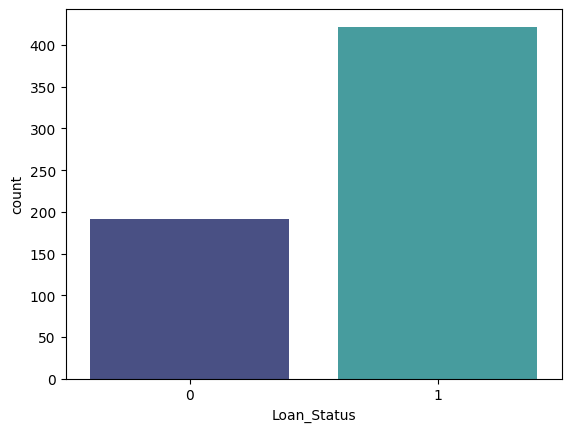

In [ ]:
sns.countplot(data=df, x='Loan_Status', palette='mako')

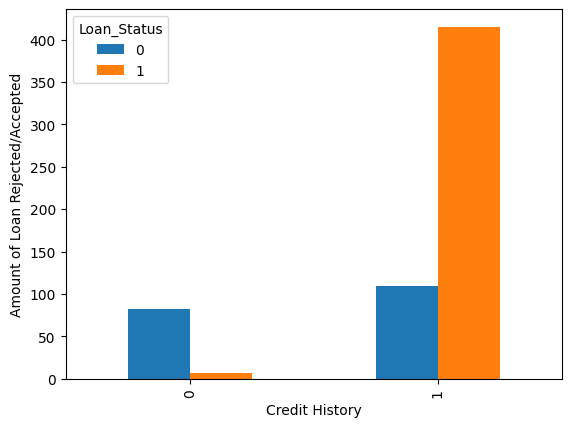

In [ ]:
pd.crosstab(df['Credit_History'], df['Loan_Status']).plot(kind='bar')
plt.xlabel('Credit History')
plt.ylabel('Amount of Loan Rejected/Accepted')
plt.show()

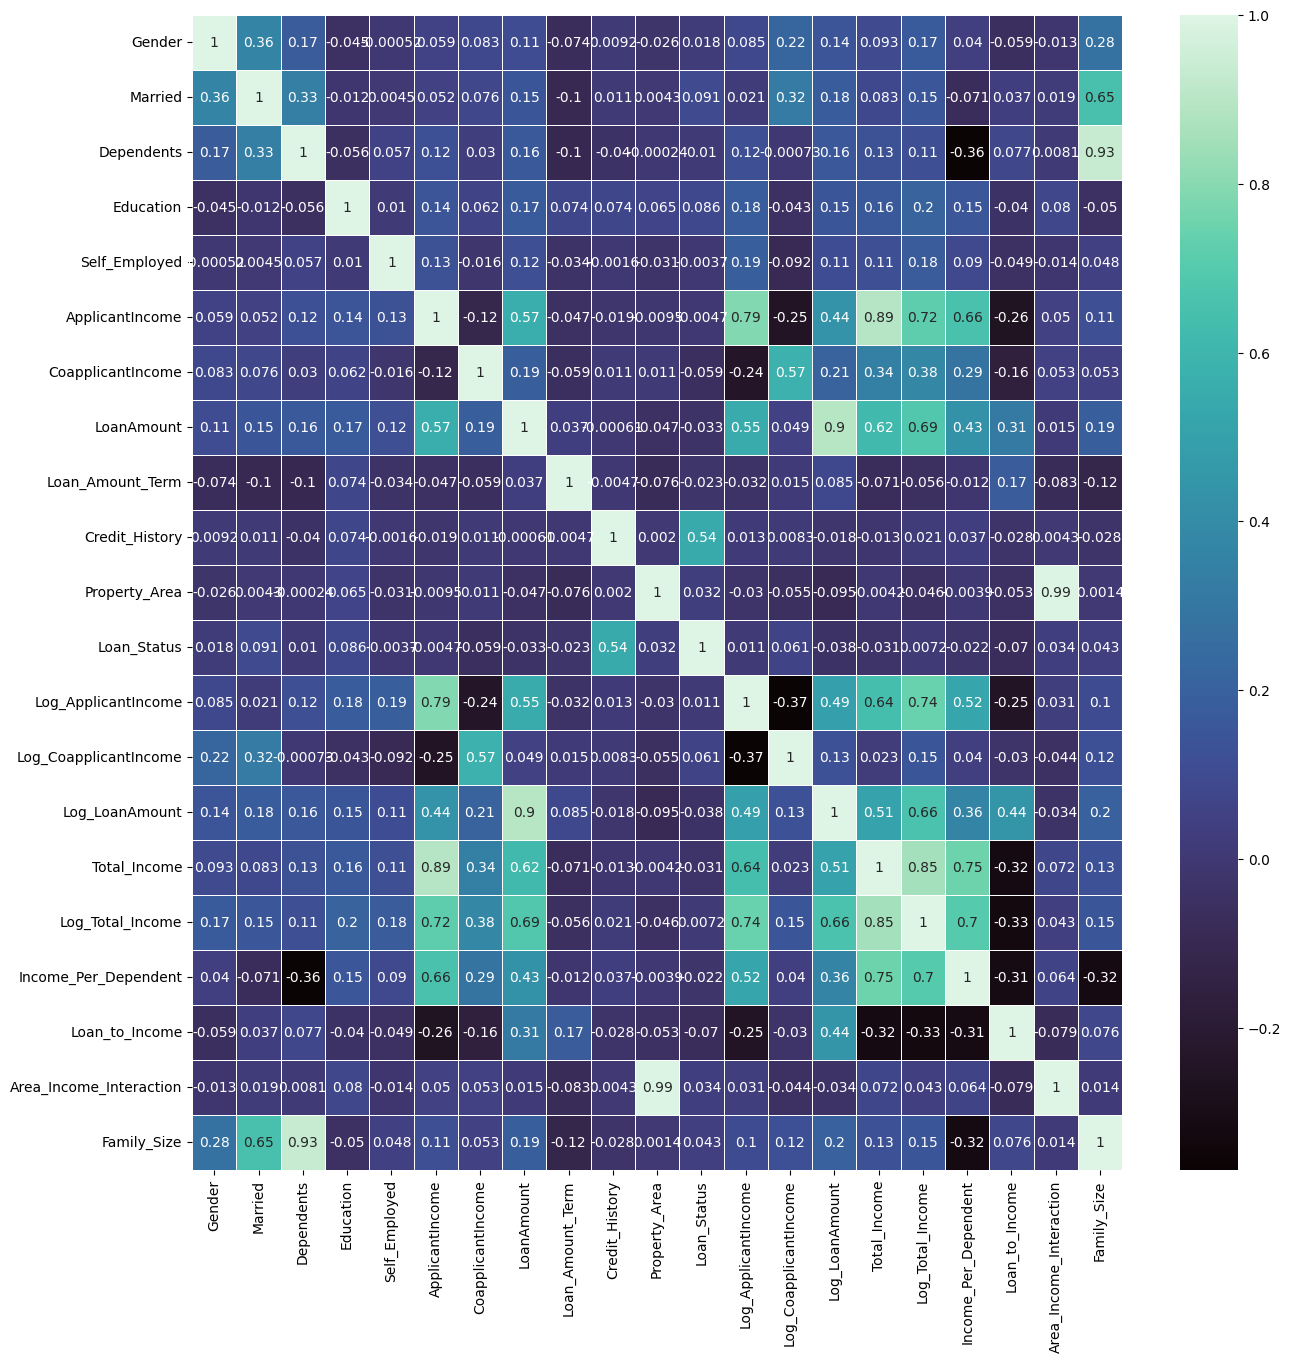

In [ ]:
plt.figure(figsize=(15,15))
corr=df.drop(columns=['Loan_ID']).corr()
sns.heatmap(corr,annot=True,linewidth=.5,cmap='mako')
plt.show()

# Feature Selection

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Log_ApplicantIncome', 'Log_CoapplicantIncome', 'Log_LoanAmount',
       'Total_Income', 'Log_Total_Income', 'Income_Per_Dependent',
       'Loan_to_Income', 'Area_Income_Interaction', 'Family_Size'],
      dtype='object')

In [ ]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area',  'Family_Size']
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Log_ApplicantIncome', 'Log_CoapplicantIncome', 'Log_LoanAmount','Log_Total_Income', 'Income_Per_Dependent', 'Loan_to_Income', 'Area_Income_Interaction']

In [ ]:
# Chi-square tests
print("CHI-SQUARE TESTS")
print("="*50)
for col in categorical_cols:
    contingency = pd.crosstab(df[col].dropna(), df.loc[df[col].notna(), 'Loan_Status'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    status = "Significant" if p_val < 0.05 else "Not Significant"
    print(f"  {col}: χ²={chi2:.2f}, p={p_val:.4f} [{status}]")

# T-tests
print("\nT-TESTS")
print("="*50)
for col in numerical_cols:
    approved = df[df['Loan_Status'] == 1][col].dropna()
    rejected = df[df['Loan_Status'] == 0][col].dropna()
    t_stat, p_val = ttest_ind(approved, rejected)
    status = "Significant" if p_val < 0.05 else "Not Significant"
    print(f"  {col}: t={t_stat:.2f}, p={p_val:.4f} [{status}]")

CHI-SQUARE TESTS
  Gender: χ²=0.11, p=0.7391 [Not Significant]
  Married: χ²=4.73, p=0.0296 [Significant]
  Dependents: χ²=3.15, p=0.3689 [Not Significant]
  Education: χ²=4.09, p=0.0431 [Significant]
  Self_Employed: χ²=0.00, p=1.0000 [Not Significant]
  Credit_History: χ²=176.11, p=0.0000 [Significant]
  Property_Area: χ²=12.30, p=0.0021 [Significant]
  Family_Size: χ²=4.55, p=0.3361 [Not Significant]

T-TESTS
  ApplicantIncome: t=-0.12, p=0.9073 [Not Significant]
  CoapplicantIncome: t=-1.47, p=0.1429 [Not Significant]
  LoanAmount: t=-0.82, p=0.4113 [Not Significant]
  Loan_Amount_Term: t=-0.56, p=0.5771 [Not Significant]
  Total_Income: t=-0.77, p=0.4392 [Not Significant]
  Log_ApplicantIncome: t=0.27, p=0.7864 [Not Significant]
  Log_CoapplicantIncome: t=1.50, p=0.1337 [Not Significant]
  Log_LoanAmount: t=-0.95, p=0.3441 [Not Significant]
  Log_Total_Income: t=0.18, p=0.8581 [Not Significant]
  Income_Per_Dependent: t=-0.54, p=0.5888 [Not Significant]
  Loan_to_Income: t=-1.75, 

In [ ]:
df_reduced = df.drop(columns = ['Loan_ID','Gender', 'Dependents', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income', 'Loan_Amount_Term'])

In [ ]:
df_reduced.head()

,Married,Education,Credit_History,Property_Area,Loan_Status,Log_ApplicantIncome,Log_CoapplicantIncome,Log_LoanAmount,Log_Total_Income,Income_Per_Dependent,Loan_to_Income,Area_Income_Interaction,Family_Size
0,0,1,1,2,1,8.674197,0.000000,4.859812,8.674197,5849.0,18.688860,17.348394,1
1,1,1,1,0,0,8.430327,7.319202,4.859812,8.714732,3045.5,18.051051,0.000000,3
2,1,1,1,2,1,8.006701,0.000000,4.204693,8.006701,3000.0,16.500000,16.013402,2
3,1,0,1,2,1,7.857094,7.765993,4.795791,8.505525,4941.0,20.198620,17.011051,2
4,0,1,1,2,1,8.699681,0.000000,4.955827,8.699681,6000.0,20.142857,17.399363,1


In [ ]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Married                  614 non-null    int64  
 1   Education                614 non-null    int64  
 2   Credit_History           614 non-null    int64  
 3   Property_Area            614 non-null    int64  
 4   Loan_Status              614 non-null    int64  
 5   Log_ApplicantIncome      614 non-null    float64
 6   Log_CoapplicantIncome    614 non-null    float64
 7   Log_LoanAmount           614 non-null    float64
 8   Log_Total_Income         614 non-null    float64
 9   Income_Per_Dependent     614 non-null    float64
 10  Loan_to_Income           614 non-null    float64
 11  Area_Income_Interaction  614 non-null    float64
 12  Family_Size              614 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 62.5 KB


# Data Preprocessing for Test Dataset

## Data Preview

In [ ]:
df_test = pd.read_csv('test.csv')
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


## Handling Missing Value

In [ ]:
df_test[df_test.isna().any(axis=1)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0,280.0,240.0,1.0,Urban
11,LP001082,Male,Yes,1,Graduate,NaN,2185,1516,162.0,360.0,1.0,Semiurban
12,LP001083,Male,No,3+,Graduate,No,4166,0,40.0,180.0,NaN,Urban
13,LP001094,Male,Yes,2,Graduate,NaN,12173,0,166.0,360.0,0.0,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...,...
336,LP002853,Female,No,0,Not Graduate,No,3015,2000,145.0,360.0,NaN,Urban
351,LP002901,Male,No,0,Graduate,No,2283,15000,106.0,360.0,NaN,Rural
358,LP002954,Male,Yes,2,Not Graduate,No,3132,0,76.0,360.0,NaN,Rural
360,LP002965,Female,Yes,0,Graduate,No,8550,4255,96.0,360.0,NaN,Urban


In [ ]:
df_test.isna().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [ ]:
for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term', 'Property_Area']:
  df_test[col].replace(np.nan,df_test[col].mode()[0],inplace=True)
  print(f'{col} mode: {df_test[col].mode()[0]}')

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
  df_test[col].replace(np.nan,df_test[col].median(),inplace=True)
  print(f'{col} median: {df_test[col].median()}')

Gender mode: Male
Married mode: Yes
Dependents mode: 0
Education mode: Graduate
Self_Employed mode: No
Credit_History mode: 1.0
Loan_Amount_Term mode: 360.0
Property_Area mode: Urban
ApplicantIncome median: 3786.0
CoapplicantIncome median: 1025.0
LoanAmount median: 125.0


/tmp/ipykernel_8660/1437881388.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test[col].replace(np.nan,df_test[col].mode()[0],inplace=True)
/tmp/ipykernel_8660/1437881388.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
 10  Credit_History     367 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


## Feature Engineering

In [ ]:
df_test['Gender'] = df_test['Gender'].replace({'Male':1, 'Female':0})
df_test['Married'] = df_test['Married'].replace({'Yes':1, 'No':0})
df_test['Self_Employed'] = df_test['Self_Employed'].replace({'Yes':1, 'No':0})
df_test['Education'] = df_test['Education'].replace({'Graduate':1, 'Not Graduate':0})
df_test['Property_Area'] = df_test['Property_Area'].replace({'Urban':2, 'Semiurban':1, 'Rural':0})
df_test['Dependents'] = df_test['Dependents'].replace('3+', 3)
df_test[['Married', 'Self_Employed', 'Education', 'Property_Area', 'Dependents']] = df_test[['Married', 'Self_Employed', 'Education', 'Property_Area', 'Dependents']].astype(int)

/tmp/ipykernel_8660/2344097296.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['Gender'] = df_test['Gender'].replace({'Male':1, 'Female':0})
/tmp/ipykernel_8660/2344097296.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['Married'] = df_test['Married'].replace({'Yes':1, 'No':0})
/tmp/ipykernel_8660/2344097296.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to

In [ ]:
df_test['Log_ApplicantIncome']=np.log1p(df_test['ApplicantIncome'])
df_test['Log_CoapplicantIncome']=np.log1p(df_test['CoapplicantIncome'])
df_test['Log_LoanAmount']=np.log1p(df_test['LoanAmount'])

In [ ]:
df_test['Total_Income'] = df_test['ApplicantIncome'] + df_test['CoapplicantIncome']
df_test['Log_Total_Income'] = np.log1p(df_test['Total_Income'])
print("Total_Income created")

df_test['Income_Per_Dependent'] = df_test['Total_Income'] / (df_test['Dependents'] + 1)
print("Income_Per_Dependent created")

df_test['Loan_to_Income'] = df_test['LoanAmount'] / (df_test['Total_Income'] / 1000 + 1)
print("Loan_to_Income created")

df_test['Area_Income_Interaction'] = df_test['Property_Area'] * df_test['Log_Total_Income']
print("Area_Income_Interaction created")

df_test['Family_Size'] = df_test['Dependents'] + df_test['Married'] + 1
print("Family_Size created")

Total_Income created
Income_Per_Dependent created
Loan_to_Income created
Area_Income_Interaction created
Family_Size created


In [ ]:
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,...,Property_Area,Log_ApplicantIncome,Log_CoapplicantIncome,Log_LoanAmount,Total_Income,Log_Total_Income,Income_Per_Dependent,Loan_to_Income,Area_Income_Interaction,Family_Size
0,LP001015,1,1,0,1,0,5720,0,110.0,360.0,...,2,8.651899,0.000000,4.709530,5720,8.651899,5720.000000,16.369048,17.303798,2
1,LP001022,1,1,1,1,0,3076,1500,126.0,360.0,...,2,8.031710,7.313887,4.844187,4576,8.428799,2288.000000,22.596844,16.857598,3
2,LP001031,1,1,2,1,0,5000,1800,208.0,360.0,...,2,8.517393,7.496097,5.342334,6800,8.824825,2266.666667,26.666667,17.649650,4
3,LP001035,1,1,2,1,0,2340,2546,100.0,360.0,...,2,7.758333,7.842671,4.615121,4886,8.494334,1628.666667,16.989467,16.988668,4
4,LP001051,1,0,0,0,0,3276,0,78.0,360.0,...,2,8.094684,0.000000,4.369448,3276,8.094684,3276.000000,18.241347,16.189367,1


## Feature Seelection

In [ ]:
df_test.drop(columns = ['Loan_ID','Gender', 'Dependents', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income', 'Loan_Amount_Term'], inplace=True)

# Splitting the data

In [ ]:
df_train = df_reduced

X_train, X_test, y_train, y_test = train_test_split(df_train.drop(columns=['Loan_Status']), df_train['Loan_Status'], test_size=0.2, random_state=42)

# Model

## Classifier

In [ ]:
LogR = LogisticRegression()
DT = DecisionTreeClassifier()
RF = RandomForestClassifier()
XGB = XGBClassifier()

## Training

In [ ]:
LogR.fit(X_train, y_train)
DT.fit(X_train, y_train)
RF.fit(X_train, y_train)
XGB.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Prediction

In [ ]:
LogR_y_pred = LogR.predict(X_test)
DT_y_pred = DT.predict(X_test)
RF_y_pred = RF.predict(X_test)
XGB_y_pred = XGB.predict(X_test)

## Report

In [ ]:
print('\033[1m Logistic Regression -\n \033[0m', classification_report(y_test, LogR_y_pred) + '\n')
print('\033[1m Decision Tree -\n \033[0m', classification_report(y_test, DT_y_pred) + '\n')
print('\033[1m Random Forest -\n \033[0m', classification_report(y_test, RF_y_pred) + '\n')
print('\033[1m XG Boost -\n \033[0m', classification_report(y_test, XGB_y_pred) + '\n')

 Logistic Regression -
                precision    recall  f1-score   support

           0       0.71      0.35      0.47        43
           1       0.73      0.93      0.81        80

    accuracy                           0.72       123
   macro avg       0.72      0.64      0.64       123
weighted avg       0.72      0.72      0.69       123


 Decision Tree -
                precision    recall  f1-score   support

           0       0.49      0.49      0.49        43
           1       0.72      0.72      0.72        80

    accuracy                           0.64       123
   macro avg       0.61      0.61      0.61       123
weighted avg       0.64      0.64      0.64       123


 Random Forest -
                precision    recall  f1-score   support

           0       0.75      0.56      0.64        43
           1       0.79      0.90      0.84        80

    accuracy                           0.78       123
   macro avg       0.77      0.73      0.74       123
weighted 

## ROC Curve

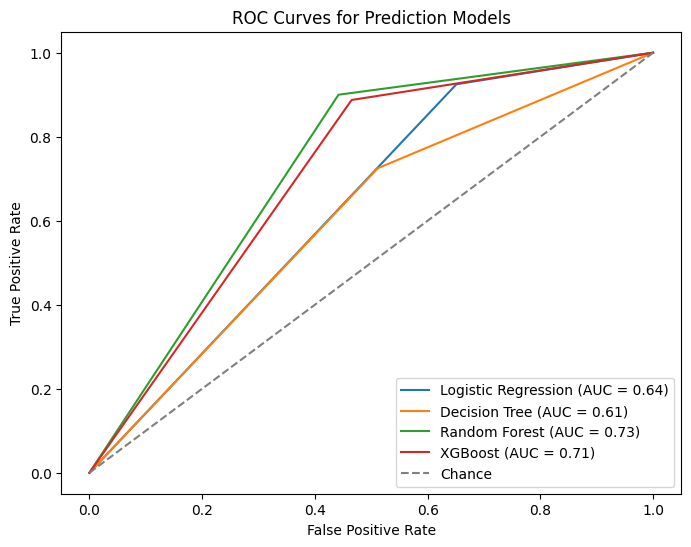

In [ ]:
def plot_roc_curves(y_true_test, LogisticRegression_result,
                    DecisionTree_result,
                    RandomForest_result,
                    XGB_result):
    plt.figure(figsize=(8, 6))

    # Calculate ROC curves for each model
    fpr_logr, tpr_logr, _ = roc_curve(y_true_test, LogisticRegression_result)
    fpr_dt, tpr_dt, _ = roc_curve(y_true_test, DecisionTree_result)
    fpr_rf, tpr_rf, _ = roc_curve(y_true_test, RandomForest_result)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_true_test, XGB_result)

    # Calculate AUC for each model
    auc_logr = auc(fpr_logr, tpr_logr)
    auc_dt = auc(fpr_dt, tpr_dt)
    auc_rf = auc(fpr_rf, tpr_rf)
    auc_xgb = auc(fpr_xgb, tpr_xgb)

    # Plot ROC curves
    plt.plot(fpr_logr, tpr_logr, label=f'Logistic Regression (AUC = {auc_logr:.2f})')
    plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
    plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')

    # Plot random classifier
    plt.plot([0,1], [0,1], linestyle = '--', color = 'gray', label='Chance')

    # Format the plot
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Prediction Models')
    plt.legend()
    plt.show()

plot_roc_curves(y_test,
                LogR_y_pred,
                DT_y_pred,
                RF_y_pred,
                XGB_y_pred)